# IMDB数据集的二分类情感分析

大纲如下：
- [Model](#Model-Part)
- [DataLoader](#DataLoader-Part)
- [Train_loop & Test_loop](#Train_loop-Part)
- [Controller](#Controller-Part)
- [Console](#Console-Part)
- [Evaluater](#Evaluater-Part)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
from typing import Callable
from pathlib import Path
import torch.optim as optim
import math
from torch.utils.data import DataLoader, Dataset

DATAPATH = "."

/opt/miniconda3/envs/pytorch/lib/python3.11/site-packages/torch_npu/utils/collect_env.py:58: UserWarning: Warning: The /usr/local/Ascend/ascend-toolkit/latest owner does not match the current owner.
  warnings.warn(f"Warning: The {path} owner does not match the current owner.")
/opt/miniconda3/envs/pytorch/lib/python3.11/site-packages/torch_npu/utils/collect_env.py:58: UserWarning: Warning: The /usr/local/Ascend/ascend-toolkit/8.3.RC2/aarch64-linux/ascend_toolkit_install.info owner does not match the current owner.
  warnings.warn(f"Warning: The {path} owner does not match the current owner.")
/opt/miniconda3/envs/pytorch/lib/python3.11/site-packages/torch_npu/utils/_path_manager.py:66: UserWarning: Permission mismatch: The owner of /opt/miniconda3/envs/pytorch/lib/python3.11/site-packages/torch_npu/lib/libop_plugin_atb.so does not match.
  warnings.warn(f"Permission mismatch: The owner of {path} does not match.")
/opt/miniconda3/envs/pytorch/lib/python3.11/site-packages/torch_npu/util

## `Model` Part

### LSTM

- `nn.LSTM`: 应用一个多层的长短期记忆网络（LSTM）到输入序列中。对于输入序列中的每一个元素，每一层执行以下计算：
  $$
  \begin{aligned}
   i_t &= \sigma(W_{\text{ii}}x_t + b_{\text{ii}} + W_{\text{hi}}h_{t-1} + b_{\text{hi}}) \\
   f_t &= \sigma(W_{\text{if}}x_t + b_{\text{if}} + W_{\text{hf}}h_{t-1} + b_{\text{hf}}) \\
   g_t &= \tanh(W_{\text{ig}}x_t + b_{\text{ig}} + W_{\text{hg}}h_{t-1} + b_{\text{hg}}) \\
   o_t &= \sigma(W_{\text{io}}x_t + b_{\text{io}} + W_{\text{ho}}h_{t-1} + b_{\text{ho}}) \\
   \color{orange}{c_t} \, &\color{orange}{=f_t \odot c_{t-1} + i_t \odot g_t} \\
   h_t &= o_t \odot \tanh(c_t)
   \end{aligned}
   $$
   其中：
   - $h_t$ 表示时间步 $t$ 的隐藏状态；
   - $c_t$ 表示时间步 $t$ 的神经元状态（cell state）；
   - $x_t$ 是时间步 $t$ 的输入；
   - $h_{t-1}$ 是前一个时间步的隐藏状态，或者是初始的隐藏状态（当 $t = 0$ 时）；
   - $i_t, f_t, g_t, o_t$ 分别是输入门、遗忘门、候选状态、输出门；
   - $\sigma$ 是 sigmoid 激活函数；
   - $\odot$ 表示 Hadamard（元素乘）运算。

- `LSTM`: 由一个`lstm`网络和一个全连接网络`FNN`组成

   `forward`: 
   $$
   \begin{aligned}
   \text{output}, \textcolor{orange}{hidden},\text{cell} = \text{lstm}(\text{input}) \\
   \text{probs} = \text{Softmax}(\text{FNN}(\textcolor{orange}{hidden}))
   \end{aligned}
   $$

In [2]:
class LSTM(nn.Module):
    def __init__(self, 
                vocab_size : int, 
                embedding_dim : int, 
                hidden_dim : int, 
                n_layers:int = 1,
                dropout:float = 0.2):
        super(LSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, 
                            hidden_dim, 
                            num_layers = n_layers, 
                            batch_first=True, 
                            dropout=dropout if n_layers > 1 else 0
                            )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 2) # 二分类问题
    
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden_t, _) = self.lstm(embedded)
        logits = self.fc(self.dropout(hidden_t[-1, :, :]))
        return logits


## `DataLoader` Part

- `IMDBDataset`：我们实现了`Pytorch`抽象类`Dataset`的一个子类，用于我们文本分类的任务。（所有`Dataset`子类必须要实现`__getitem__`方法，可选择实现`__len__`方法用于返回数据集的大小）

`prepare_data_loader`: 准备训练和测试的数据加载器的函数。此函数加载数据集，将其分为训练集和测试集，并创建相应的数据加载器。数据加载过程使用`PyTorch`的`DataLoader`进行并行处理，以提高数据加载效率。工作流程：  
- 从指定路径加载数据集
- 根据给定比例将数据集分为训练集和测试集
- 为训练集和测试集创建`Dataset`对象
- 配置数据加载器，设置批量大小、工作进程数等

返回一个包含训练和测试数据集的字典（{"train": `train_loader`, "test": `test_loader`}）

In [3]:
class IMDBDataset(Dataset):
    def __init__(self, x, y):
        self._x = x
        self._y = y

    def __getitem__(self, idx):
        return {
            "encoded_indices": torch.tensor(self._x[idx], dtype=torch.long),
            "label": torch.tensor(self._y[idx], dtype=torch.long),
        }

    def __len__(self):
        return len(self._x)


def prepare_data_loader(
    path: str,
    ratio: float,
    batch_size: int,
    num_workers: int = 4,
) -> dict:
    """
    参数:
        path (str): .npz格式的数据集文件路径
        ratio (float, optional): 用于训练的数据比例(默认为0.8)
        seed (int, optional): 用于随机打乱的种子(默认为12)
        batch_size (int, optional): 训练批量大小(默认为128)
        num_workers (int, optional): 数据加载的工作进程数(默认为4)

    返回:
        dict: 包含训练和测试数据加载器的字典
    """
    train_data = np.load(path)

    x_data = train_data["x_train"]
    y_data = train_data["y_train"]

    num_samples = len(x_data)
    split_idx = int(num_samples * ratio)
    x_train = x_data[:split_idx]
    y_train = y_data[:split_idx]
    x_test = x_data[split_idx:]
    y_test = y_data[split_idx:]

    train_batch_size = batch_size
    test_batch_size = train_batch_size

    # 创建PyTorch数据集
    train_dataset = IMDBDataset(x_train, y_train)
    test_dataset = IMDBDataset(x_test, y_test)

    # 创建数据加载器
    train_loader = DataLoader(
        dataset=train_dataset,
        batch_size=train_batch_size,
        shuffle=True,
        num_workers=num_workers,
        drop_last=True,
    )

    test_loader = DataLoader(
        dataset=test_dataset,
        batch_size=test_batch_size,
        shuffle=False,
        num_workers=num_workers,
    )

    return {"train": train_loader, "test": test_loader}

## `Train_loop` Part
这一部分是实现神经网络在一个训练周期中的两个关键步骤：
- 在训练集上面计算损失，并依据损失更新参数
- 在测试集上面计算度量(Metric)，跟踪当前参数下的泛化性能

我们实现了`train_step`和`eval_step`两个函数分别执行单步(step)的训练步骤和测试步骤，`train_per_epoch`和`test_per_epoch`两个函数分别执行一个回合(epoch)的训练步骤和测试步骤。对于深度学习而言，一个`step`包含对一批(`batch`)数据的处理，一个`epoch`包含多个`step`，当把数据集的数据都训练过一遍，我们称为一个`epoch`，也就是说当数据集能被`batch`整除的时候，有:
$$ \text{batch\_sizes} * \text{num\_steps} = \text{total\_data} $$

`train_per_epoch` : 此函数处理一个完整`epoch`的训练过程:
- 设置模型为训练模式
- 遍历训练数据加载器中的所有批次
- 对每个批次执行前向和后向传播并使用优化器更新模型参数
- 使用进度条跟踪和显示训练指标

`test_per_epoch` : 此函数处理一个完整`epoch`训练后的评估过程:
- 设置模型为评估模式
- 遍历测试数据加载器中的所有批次
- 在不更新梯度的情况下计算前向传播
- 计算评估指标（损失、准确率等），记录并显示评估结果


In [4]:
from datetime import datetime
import time

def train_step(
    model: nn.Module, 
    loss_fn: Callable, 
    optimizer: optim.Optimizer, 
    batch: dict, 
    device: torch.device
):
    model.train()
    optimizer.zero_grad()

    batch_tokens = batch["encoded_indices"].to(device)
    labels = batch["label"].to(device)

    logits = model(batch_tokens)
    loss = loss_fn(logits, labels)

    loss.backward()
    optimizer.step()

    _, predicted = torch.max(logits, 1)
    correct = (predicted == labels).sum().item()
    total = labels.size(0)

    return loss.item(), correct, total


def eval_step(model: nn.Module, metric_fn: Callable, batch: dict, device: torch.device):
    model.eval()
    with torch.no_grad():
        batch_tokens = batch["encoded_indices"].to(device)
        labels = batch["label"].to(device)
        logits = model(batch_tokens)
        metric = metric_fn(logits, labels)

        return metric.item(), logits, labels


def train_per_epoch(
    model: nn.Module,
    loss_fn: Callable,
    optimizer: optim.Optimizer,
    train_loader: DataLoader,
    device: torch.device,
    epoch: int,
    start_time: float,
    global_batch_counter: int,
    history: dict,
):
    """返回 (epoch_avg_loss, epoch_acc, updated_global_batch_counter)"""
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch_idx, batch in enumerate(train_loader):
        loss, correct, n = train_step(model, loss_fn, optimizer, batch, device)
        total_loss += loss
        total_correct += correct
        total_samples += n
        global_batch_counter += 1

        # 记录每个batch的loss和acc
        history["train_loss_per_batch"].append(loss)
        history["train_acc_per_batch"].append(correct / n)
        history["batch_indices"].append(global_batch_counter)

        # 每5个批次打印一次
        if (batch_idx + 1) % 5 == 0:
            elapsed = time.time() - start_time
            batch_acc = correct / n
            print(f"Epoch {epoch+1}, Batch {batch_idx+1}, "
                  f"Time: {elapsed:.1f}s, "
                  f"Train Loss: {loss:.4f}, Train Acc: {batch_acc*100:.1f}%")

    epoch_avg_loss = total_loss / len(train_loader)
    epoch_acc = total_correct / total_samples
    return epoch_avg_loss, epoch_acc, global_batch_counter


def test_per_epoch(
    model: nn.Module,
    metric_fn: Callable,
    test_loader: DataLoader,
    device: torch.device,
):
    """返回 (avg_loss, accuracy)"""
    model.eval()
    total_loss = 0.0
    correct = 0
    num_batches = len(test_loader)
    num_data = len(test_loader.dataset)

    with torch.no_grad():
        for batch in test_loader:
            loss, logits, labels = eval_step(model, metric_fn, batch, device)
            total_loss += loss
            _, predicted = torch.max(logits, 1)
            correct += (predicted == labels).sum().item()

    avg_loss = total_loss / num_batches
    accuracy = correct / num_data
    return avg_loss, accuracy

## `Controller` Part
这一部分是我们这份代码的控制中枢，我们实例化上文已经写好的类，调用上文已经写好的各个函数，组合起来实现我们的IMDB数据集的情感分析任务。在这一部分，我们要指定需要设定的绝大部分超参数，开展训练并得到我们训练好的模型。

In [5]:
def plot_metrics(history, epoch):
    """每5个epoch画一次loss和acc曲线，横坐标为批次数"""
    batch_x = history["batch_indices"]

    # --- Loss 图 ---
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    ax.plot(batch_x, history["train_loss_per_batch"], label="Train Loss", alpha=0.6)
    # 将val loss展开到对应的batch区间
    if history["val_loss_per_epoch"]:
        val_x = history["val_batch_x"]
        val_losses = history["val_loss_per_epoch"]
        ax.plot(val_x, val_losses, 'o-', label="Val Loss", markersize=4)
    ax.set_xlabel("Batch")
    ax.set_ylabel("Loss")
    ax.set_title(f"Loss (up to Epoch {epoch+1})")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Acc 图 ---
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    ax.plot(batch_x, history["train_acc_per_batch"], label="Train Acc", alpha=0.6)
    if history["val_acc_per_epoch"]:
        val_x = history["val_batch_x"]
        val_accs = history["val_acc_per_epoch"]
        ax.plot(val_x, val_accs, 'o-', label="Val Acc", markersize=4)
    ax.set_xlabel("Batch")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"Accuracy (up to Epoch {epoch+1})")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def controller(seed: int,
               lstm_embed: int,
               hidden_dim: int,
               ratio: float,
               batch_size: int, 
               epochs: int, 
               learning_rate: float):
    torch.manual_seed(seed)
    data_path = Path(f"{DATAPATH}/processed_imdb_train_data.npz")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = LSTM(
            vocab_size=20000,
            embedding_dim=lstm_embed,
            hidden_dim=hidden_dim,
        ).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    loss_fn = nn.CrossEntropyLoss()
    metric_fn = nn.CrossEntropyLoss()

    loader_dict = prepare_data_loader(data_path, ratio, batch_size)
    train_loader = loader_dict["train"]
    test_loader = loader_dict["test"]

    # 记录历史数据
    history = {
        "train_loss_per_batch": [],   # 每个batch的train loss
        "train_acc_per_batch": [],    # 每个batch的train acc
        "batch_indices": [],          # 全局batch编号
        "val_loss_per_epoch": [],     # 每次eval的val loss
        "val_acc_per_epoch": [],      # 每次eval的val acc
        "val_batch_x": [],            # val对应的batch x坐标(epoch结束时的batch编号)
    }

    global_batch_counter = 0
    start_time = time.time()

    for epoch in range(epochs):
        print(f"Epoch {epoch + 1} \n--------------------------------")
        train_loss, train_acc, global_batch_counter = train_per_epoch(
            model, loss_fn, optimizer, train_loader, device,
            epoch, start_time, global_batch_counter, history
        )
        # scheduler.step()

        val_loss, val_acc = test_per_epoch(model, metric_fn, test_loader, device)

        # 记录val指标(每个epoch都记录，用于画图)
        history["val_loss_per_epoch"].append(val_loss)
        history["val_acc_per_epoch"].append(val_acc)
        history["val_batch_x"].append(global_batch_counter)

        # 每5个epoch打印val信息并画图
        if (epoch + 1) % 5 == 0:
            elapsed = time.time() - start_time
            print(f"\n===== Epoch {epoch+1} Summary =====")
            print(f"Time: {elapsed:.1f}s")
            print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.1f}%")
            print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc*100:.1f}%")
            print(f"================================\n")
            plot_metrics(history, epoch)

    print("Done!")
    return model

## `Console` Part
这个板块是我们的总控制台，在这里我们设定所有的超参数，调用我们前面写好的所有类和函数，训练模型并返回我们的模型

Epoch 1 
--------------------------------
Epoch 1, Batch 5, Time: 3.1s, Train Loss: 0.6944, Train Acc: 48.8%
Epoch 1, Batch 10, Time: 4.7s, Train Loss: 0.6930, Train Acc: 49.2%
Epoch 1, Batch 15, Time: 6.4s, Train Loss: 0.6919, Train Acc: 52.7%
Epoch 1, Batch 20, Time: 8.0s, Train Loss: 0.6933, Train Acc: 49.8%
Epoch 2 
--------------------------------
Epoch 2, Batch 5, Time: 10.7s, Train Loss: 0.6911, Train Acc: 55.2%
Epoch 2, Batch 10, Time: 12.4s, Train Loss: 0.6916, Train Acc: 52.7%
Epoch 2, Batch 15, Time: 14.1s, Train Loss: 0.6922, Train Acc: 51.8%
Epoch 2, Batch 20, Time: 15.8s, Train Loss: 0.6903, Train Acc: 53.6%
Epoch 3 
--------------------------------
Epoch 3, Batch 5, Time: 18.7s, Train Loss: 0.6917, Train Acc: 52.7%
Epoch 3, Batch 10, Time: 20.4s, Train Loss: 0.6908, Train Acc: 52.9%
Epoch 3, Batch 15, Time: 22.1s, Train Loss: 0.6917, Train Acc: 52.9%
Epoch 3, Batch 20, Time: 23.7s, Train Loss: 0.6899, Train Acc: 52.9%
Epoch 4 
--------------------------------
Epoch 4, Ba

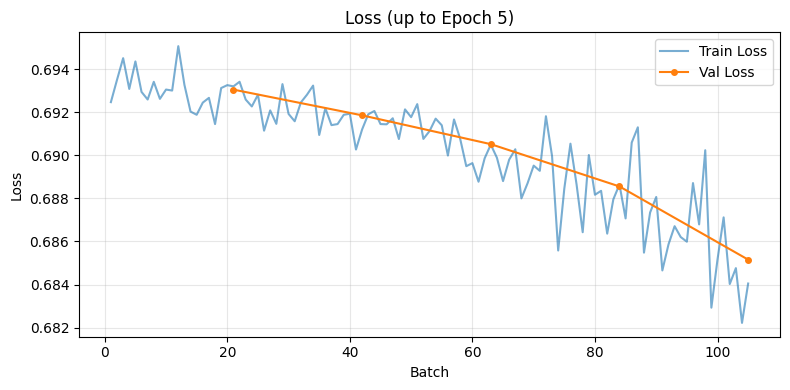

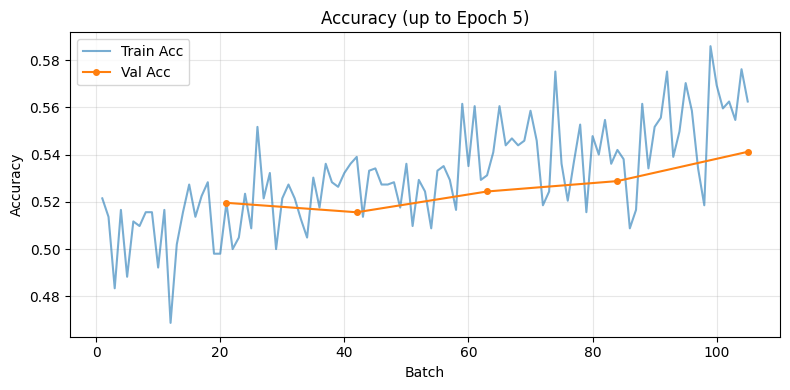

Epoch 6 
--------------------------------
Epoch 6, Batch 5, Time: 43.2s, Train Loss: 0.6848, Train Acc: 54.6%
Epoch 6, Batch 10, Time: 44.8s, Train Loss: 0.6829, Train Acc: 54.3%
Epoch 6, Batch 15, Time: 46.5s, Train Loss: 0.6782, Train Acc: 56.2%
Epoch 6, Batch 20, Time: 48.2s, Train Loss: 0.6813, Train Acc: 56.2%
Epoch 7 
--------------------------------
Epoch 7, Batch 5, Time: 51.1s, Train Loss: 0.6668, Train Acc: 59.7%
Epoch 7, Batch 10, Time: 52.8s, Train Loss: 0.6663, Train Acc: 60.8%
Epoch 7, Batch 15, Time: 54.5s, Train Loss: 0.6717, Train Acc: 57.6%
Epoch 7, Batch 20, Time: 56.2s, Train Loss: 0.6551, Train Acc: 62.8%
Epoch 8 
--------------------------------
Epoch 8, Batch 5, Time: 59.1s, Train Loss: 0.6573, Train Acc: 61.9%
Epoch 8, Batch 10, Time: 60.7s, Train Loss: 0.6387, Train Acc: 64.8%
Epoch 8, Batch 15, Time: 62.4s, Train Loss: 0.6521, Train Acc: 61.4%
Epoch 8, Batch 20, Time: 64.1s, Train Loss: 0.6373, Train Acc: 63.1%
Epoch 9 
--------------------------------
Epoch 9

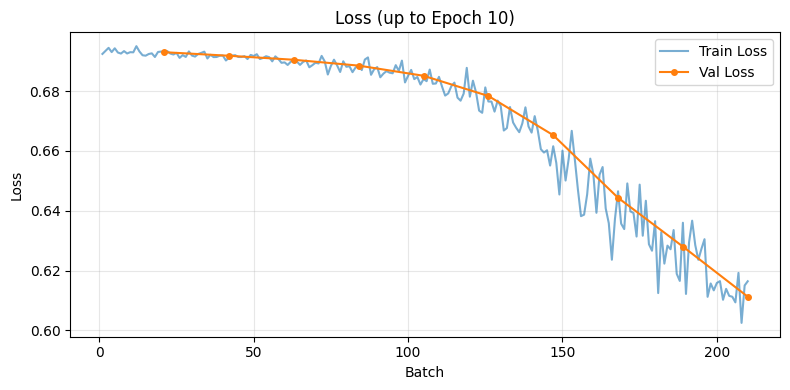

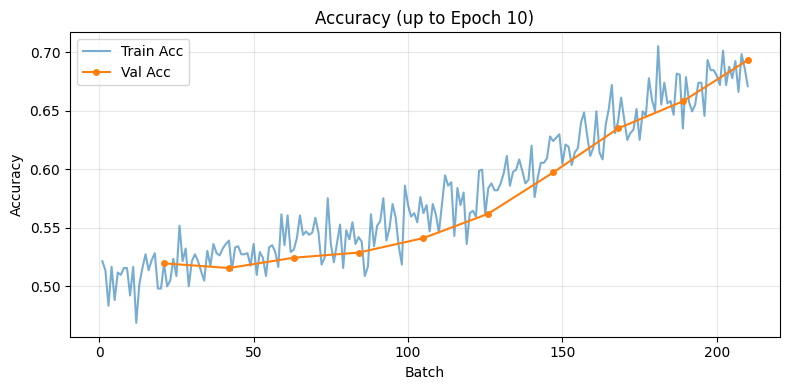

Epoch 11 
--------------------------------
Epoch 11, Batch 5, Time: 83.6s, Train Loss: 0.6165, Train Acc: 67.1%
Epoch 11, Batch 10, Time: 85.3s, Train Loss: 0.5909, Train Acc: 70.9%
Epoch 11, Batch 15, Time: 87.0s, Train Loss: 0.5968, Train Acc: 70.3%
Epoch 11, Batch 20, Time: 88.7s, Train Loss: 0.6027, Train Acc: 69.3%
Epoch 12 
--------------------------------
Epoch 12, Batch 5, Time: 91.7s, Train Loss: 0.6041, Train Acc: 69.3%
Epoch 12, Batch 10, Time: 93.4s, Train Loss: 0.5853, Train Acc: 71.4%
Epoch 12, Batch 15, Time: 95.1s, Train Loss: 0.5965, Train Acc: 69.3%
Epoch 12, Batch 20, Time: 96.7s, Train Loss: 0.5960, Train Acc: 70.7%
Epoch 13 
--------------------------------
Epoch 13, Batch 5, Time: 99.6s, Train Loss: 0.5905, Train Acc: 70.4%
Epoch 13, Batch 10, Time: 101.2s, Train Loss: 0.5908, Train Acc: 70.8%
Epoch 13, Batch 15, Time: 102.9s, Train Loss: 0.5862, Train Acc: 71.2%
Epoch 13, Batch 20, Time: 104.6s, Train Loss: 0.5813, Train Acc: 72.1%
Epoch 14 
---------------------

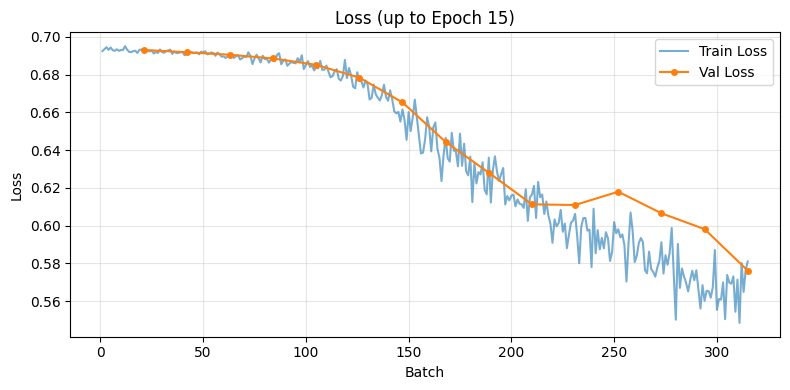

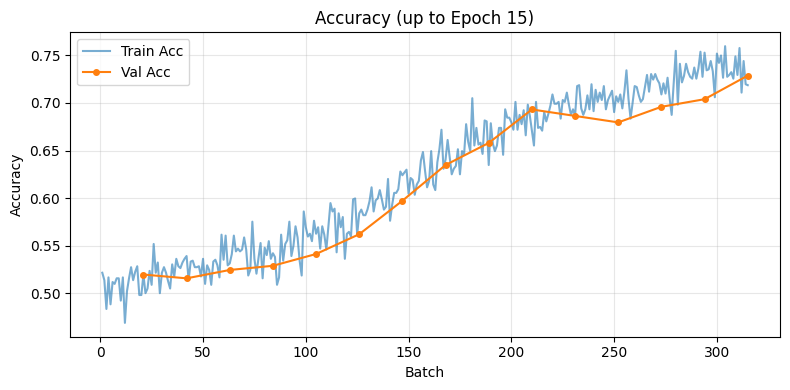

Epoch 16 
--------------------------------
Epoch 16, Batch 5, Time: 124.1s, Train Loss: 0.5566, Train Acc: 75.3%
Epoch 16, Batch 10, Time: 125.8s, Train Loss: 0.5666, Train Acc: 74.8%
Epoch 16, Batch 15, Time: 127.5s, Train Loss: 0.5461, Train Acc: 75.3%
Epoch 16, Batch 20, Time: 129.1s, Train Loss: 0.5670, Train Acc: 74.0%
Epoch 17 
--------------------------------
Epoch 17, Batch 5, Time: 132.0s, Train Loss: 0.5551, Train Acc: 73.9%
Epoch 17, Batch 10, Time: 133.8s, Train Loss: 0.5550, Train Acc: 74.2%
Epoch 17, Batch 15, Time: 135.6s, Train Loss: 0.5310, Train Acc: 77.1%
Epoch 17, Batch 20, Time: 137.2s, Train Loss: 0.5495, Train Acc: 75.7%
Epoch 18 
--------------------------------
Epoch 18, Batch 5, Time: 140.1s, Train Loss: 0.5441, Train Acc: 76.1%
Epoch 18, Batch 10, Time: 141.9s, Train Loss: 0.5460, Train Acc: 75.1%
Epoch 18, Batch 15, Time: 143.6s, Train Loss: 0.5464, Train Acc: 75.4%
Epoch 18, Batch 20, Time: 145.3s, Train Loss: 0.5373, Train Acc: 77.0%
Epoch 19 
------------

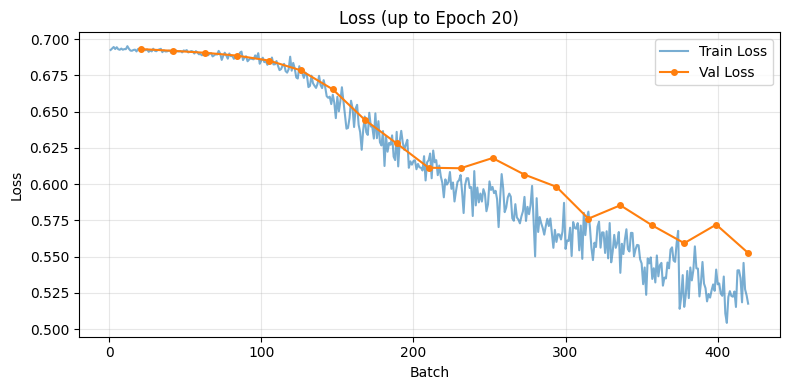

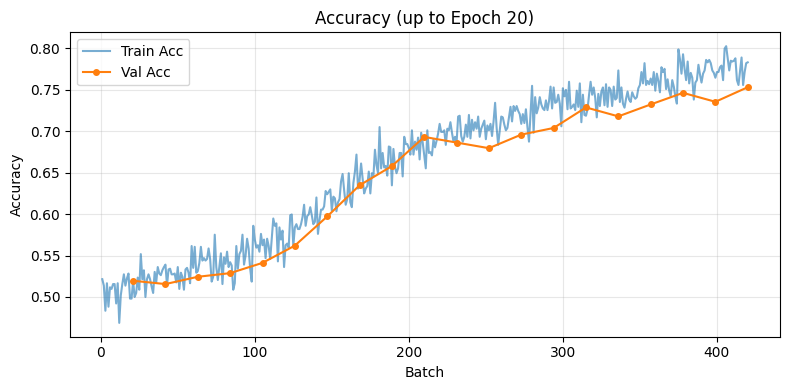

Done!


In [6]:
#随机数种子:确保每次运行代码得到相同的结果
#请同学把随机种子改成自己的学号，方便助教后期验证结果的真实性。
seed = 【这里改成学号后八位】
# 例如：
# seed = 12345678

# Transformer模型相关的超参数, 如果是LSTM则不需要关注
embed_dim = 32
num_heads = 2
ff_dim = 32
num_blocks = 2

# LSTM模型相关的超参数

lstm_embed = 16
hidden_dim = 16

ratio = 0.9 #训练集占数据集的比例
batch_size = 1024 # batch的大小
epochs = 20 # 训练回合数
learning_rate = 1e-3 #初始学习率的大小




model = controller(seed,
                   lstm_embed,
                   hidden_dim,
                   ratio,
                   batch_size,
                   epochs, 
                   learning_rate)

## `Evaluater` Part

<div class="alert alert-block alert-warning">
<b>这部分代码同学们不用修改调参，不会影响我们训练模型的性能。
</div>

这一部分我们调用已经训练好的模型，去预测我们`kaggle`给出的不带标签(`label`)的测试数据集，并将我们预测的结果写成一个`submission.csv`文件，放在指定的`kaggle`云文件夹下，便于自动评估我们提交模型的表现。

In [9]:
def evaluater(model: nn.Module):
    model.eval()
    test_data_path = Path(f"{DATAPATH}/processed_imdb_test_data.npz")
    submission_path = Path(f"{DATAPATH}/submission.csv")
    with torch.no_grad():
        test_data = np.load(test_data_path)
        test_ids = test_data["ID"]
        test_tokens = test_data["x_test"]
        for i in range(5):
            batch_test_tokens = torch.tensor(test_tokens[5000*i: 5000*(i+1), :], dtype=torch.long)
            probs = model(batch_test_tokens)
            _, batch_predicted_labels = torch.max(probs, dim=-1)
            if i == 0:
                predicted_labels = batch_predicted_labels.numpy()
            else:
                predicted_labels = np.hstack((predicted_labels, batch_predicted_labels.cpu().numpy()))

    predicted_labels = pd.DataFrame(predicted_labels, index=test_ids, columns=["label"])
    predicted_labels.to_csv(submission_path, index=True, index_label="ID")

evaluater(model)
